
--- Synthetic reconstruction 1 ---
CG info: 500

--- Synthetic reconstruction 2 ---
CG info: 500

--- CST reconstruction ---
CG info: 500


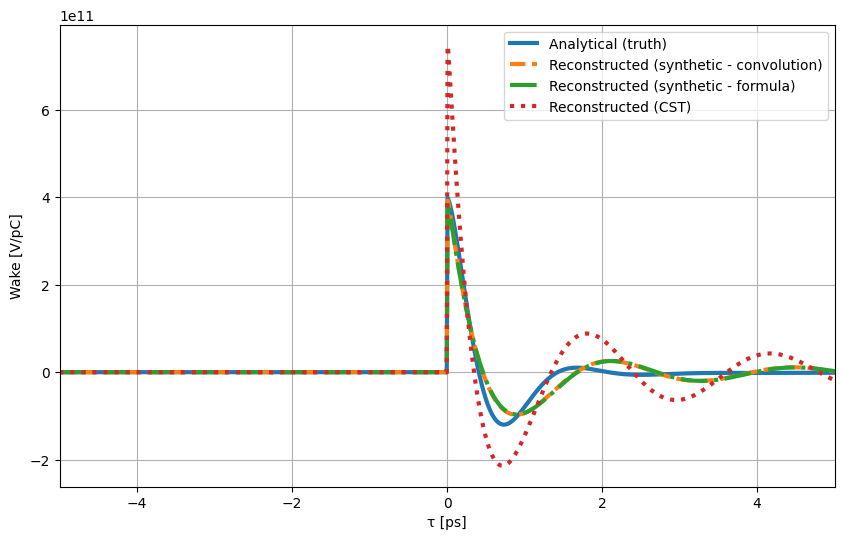

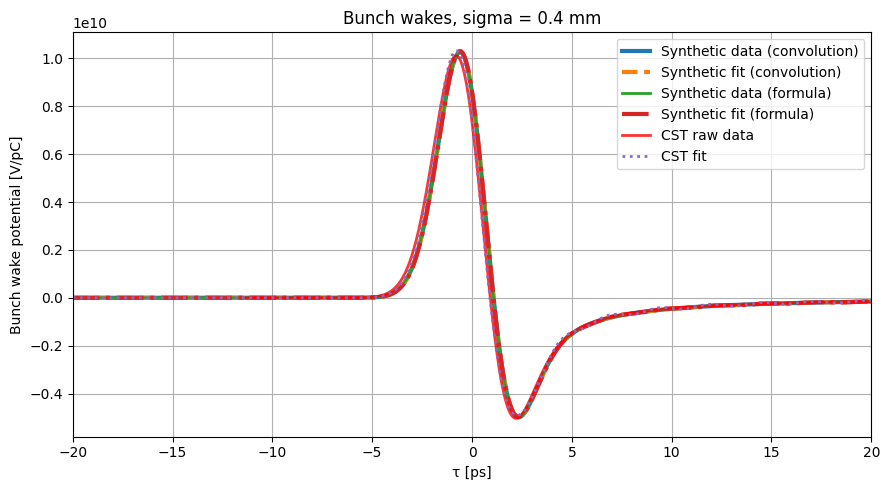

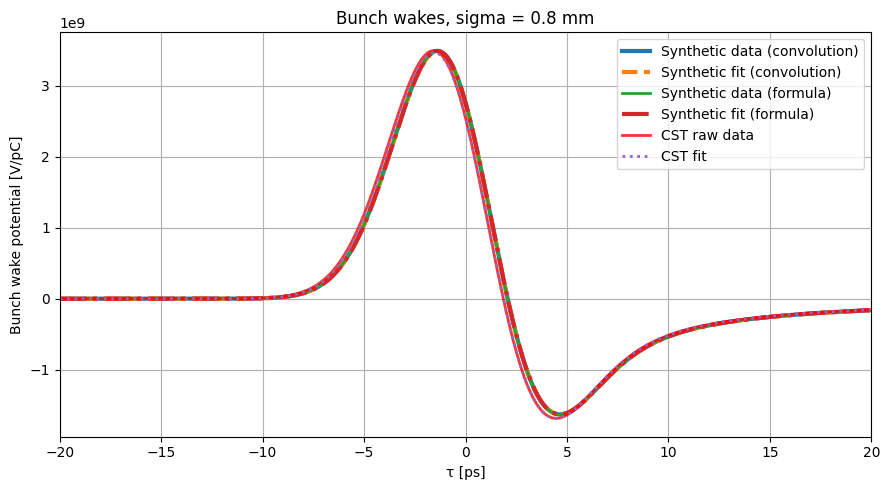

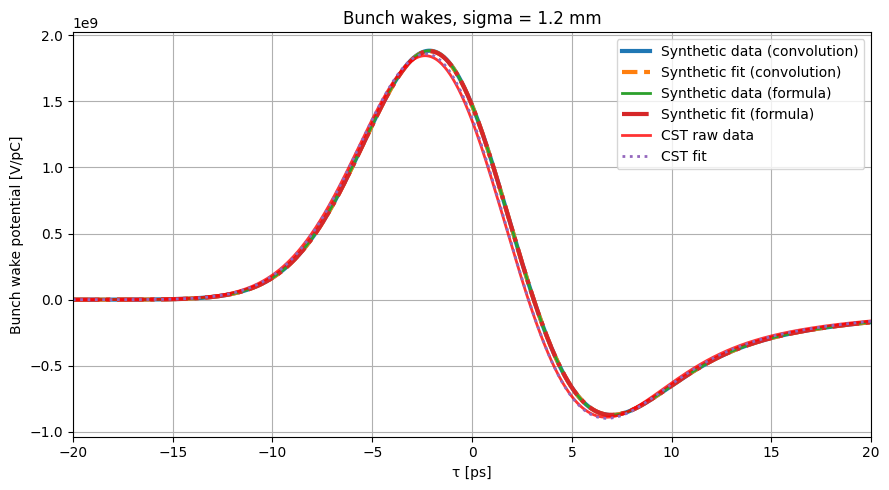

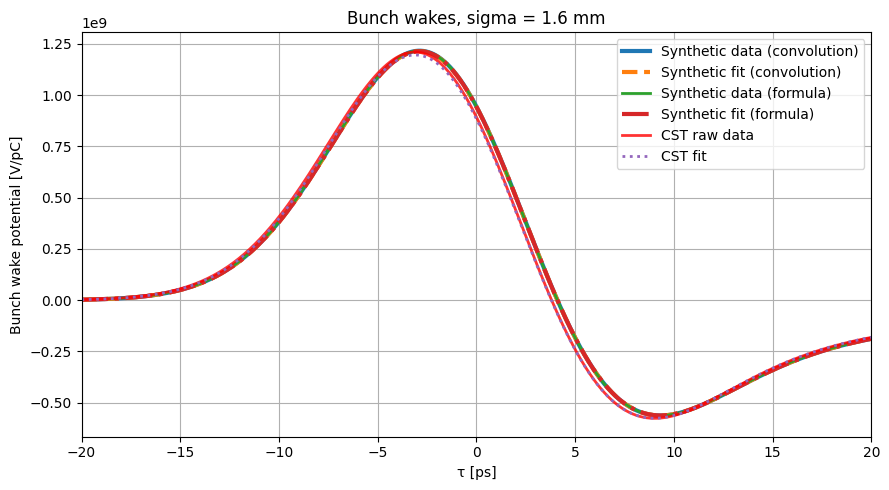

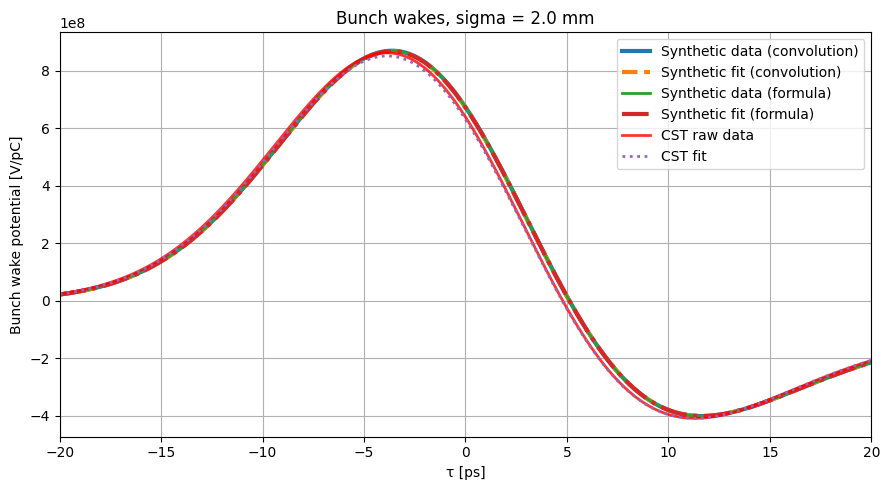

In [2]:
# Point-Charge Wake Reconstruction

import numpy as np
from pathlib import Path
from scipy.special import iv, ive
from scipy.signal import fftconvolve
from scipy.sparse.linalg import LinearOperator, cg
from scipy.constants import c, physical_constants
from scipy.interpolate import interp1d
from scipy.special import wofz
import matplotlib.pyplot as plt

# CONSTANTS
c_light = c
Z0 = physical_constants["characteristic impedance of vacuum"][0]

L = 0.01
b = 30e-3
cond = 1.45e6

# Characteristic length of RW
s0 = (2*b**2/(Z0*cond))**(1/3)
t0 = s0/c_light

# Grid
fmax = 200e12
dt = 1 / fmax
tmax = 100*t0

N = int(2*tmax/dt) + 1
t = (np.arange(N) - N//2) * dt
pad = N
i0 = np.argmin(np.abs(t))

# Extended grid
tmax_conv = 1e-10
N_conv = int(2*tmax_conv/dt) + 1
t_conv = (np.arange(N_conv) - N_conv//2) * dt

start = (N_conv - N)//2
end   = start + N

# Bunches
sigmas = [
    0.4e-3 / c_light,
    0.8e-3 / c_light,
    1.2e-3 / c_light,
    1.6e-3 / c_light,
    2.0e-3 / c_light,
]
# TODO: We need a bunch with sigma = 0.2e-3 m

lambdas = []
lambdas_full = []

for sigma in sigmas:
    lam = np.exp(-0.5*(t/sigma)**2)
    lam /= np.sum(lam) * dt
    lambdas.append(lam)

    lam_full = np.exp(-0.5*(t_conv/sigma)**2)
    lam_full /= np.sum(lam_full) * dt
    lambdas_full.append(lam_full)


# Analytical RW wakes
def wofz_ri(x, y):
    res = wofz(x + 1j*y)
    return res.real, res.imag

def LongWakeExact(t_pos, t0, factor):
    w1re,_ = wofz_ri(0, np.sqrt(2*t_pos/t0))
    w2re,_ = wofz_ri(
        np.cos(np.pi/6)*np.sqrt(2*t_pos/t0),
        np.sin(np.pi/6)*np.sqrt(2*t_pos/t0)
    )
    return factor*(4*np.exp(-t_pos/t0)*np.cos(np.sqrt(3)*t_pos/t0) + w1re - 2*w2re)

def LongitudinalWakeFunction(time, t0, radius, length):
    wl = np.zeros_like(time)
    factor = Z0*c_light/(3*np.pi*radius**2)*length
    pos = time > 0
    wl[pos] = LongWakeExact(time[pos], t0, factor)
    wl[time == 0] = 3*factor/2
    return wl

# Series expansion up to 5 terms
def W_parallel5(t, c, L, b, t0, sigma_t):
    t = np.asarray(t, dtype=float)
    out = np.zeros_like(t)

    nonzero = t != 0
    tt = t[nonzero]

    s = np.sign(tt)

    zeta = (tt / (2 * sigma_t))**2
    norm_t = tt / sigma_t
    norm_sigma_t = sigma_t / t0

    prefactor = Z0 * c * L / (16 * np.pi * b**2)
    inner = t0 * np.abs(tt) / (sigma_t**2)
    power_term = inner**1.5

    # scaled Bessel: ive(v,zeta) = exp(-zeta) * iv(v,zeta) for zeta>0
    ive_p14  = ive( 1/4, zeta)
    ive_m34  = ive(-3/4, zeta)
    ive_m14  = ive(-1/4, zeta)
    ive_p34  = ive( 3/4, zeta)

    term1_scaled = (
        -ive_p14
        + ive_m34
        - s * ive_m14
        + s * ive_p34
    )

    term3_1_scaled = (
        -s * ive_m34
        - ive_p34
    )

    term3_2_scaled = (
        ive_m14
        + s * ive_p14
    )

    out_nz = prefactor * (
        power_term * term1_scaled
        - 2 / (norm_sigma_t**3 * np.sqrt(2 * np.pi)) * (norm_t**2 - 1) * np.exp(-2 * zeta)
        + np.sqrt(np.abs(norm_t)) / (16 * norm_sigma_t**4.5) * (
            2 * norm_t**2 * (norm_t**2 - 4) * term3_1_scaled
            + (5 + 2 * norm_t**2 * (norm_t**2 - 5)) * term3_2_scaled
        )
        + 1 / (4 * np.sqrt(2 * np.pi) * norm_sigma_t**6)
          * norm_t * (15 - 10 * norm_t**2 + norm_t**4) * np.exp(-2 * zeta)
        + 1 / (32 * np.sqrt(2 * np.pi) * norm_sigma_t**9)
          * (-norm_t**8 + 28 * norm_t**6 - 210 * norm_t**4 + 420 * norm_t**2 - 105) * np.exp(-2 * zeta)
    )

    out[nonzero] = out_nz

    # FTBL-style value at t=0 from one-sided limit
    i0 = np.where(t == 0)[0]
    if len(i0) > 0:
        i0 = i0[0]
        if i0 > 0 and i0 < len(t) - 1:
            out[i0] = 0.5 * (out[i0 - 1] + out[i0 + 1])
        elif np.any(nonzero):
            eps = np.min(np.abs(tt))
            tp = np.array([eps])
            tm = np.array([-eps])

            def eval_one_side(x):
                s1 = np.sign(x)
                z1 = (x / (2 * sigma_t))**2
                nt1 = x / sigma_t
                inner1 = t0 * np.abs(x) / (sigma_t**2)

                ive_p14  = ive( 1/4, z1)
                ive_m34  = ive(-3/4, z1)
                ive_m14  = ive(-1/4, z1)
                ive_p34  = ive( 3/4, z1)

                term1 = -ive_p14 + ive_m34 - s1 * ive_m14 + s1 * ive_p34
                term31 = -s1 * ive_m34 - ive_p34
                term32 = ive_m14 + s1 * ive_p14

                return prefactor * (
                    inner1**1.5 * term1
                    - 2 / (norm_sigma_t**3 * np.sqrt(2 * np.pi)) * (nt1**2 - 1) * np.exp(-2 * z1)
                    + np.sqrt(np.abs(nt1)) / (16 * norm_sigma_t**4.5) * (
                        2 * nt1**2 * (nt1**2 - 4) * term31
                        + (5 + 2 * nt1**2 * (nt1**2 - 5)) * term32
                    )
                    + 1 / (4 * np.sqrt(2 * np.pi) * norm_sigma_t**6)
                      * nt1 * (15 - 10 * nt1**2 + nt1**4) * np.exp(-2 * z1)
                    + 1 / (32 * np.sqrt(2 * np.pi) * norm_sigma_t**9)
                      * (-nt1**8 + 28 * nt1**6 - 210 * nt1**4 + 420 * nt1**2 - 105) * np.exp(-2 * z1)
                )

            out[i0] = 0.5 * (eval_one_side(tp)[0] + eval_one_side(tm)[0])

    return out

def conv(x, h):
    x_pad = np.pad(x, pad)
    h_pad = np.pad(h, pad)
    y = fftconvolve(x_pad, h_pad, mode="same") * dt
    return y[pad:-pad]

def P(W):
    Wc = W.copy()
    Wc[t < 0] = 0.0
    if 0 < i0 < len(Wc)-1:
        Wc[i0] = 0.5 * Wc[i0+1]
    return Wc

def K(W):
    Wp = P(W)
    return np.concatenate([conv(Wp, lam) for lam in lambdas])

def KT(V_all):
    out = np.zeros(N)
    offset = 0
    for lam in lambdas:
        V = V_all[offset:offset+N]
        offset += N
        out += conv(V, lam[::-1])
    return P(out)


# Forward
def K_list(W):

    W_full = np.zeros_like(t_conv)
    W_full[start:end] = P(W)

    V_list = []

    for lam_full in lambdas_full:

        V_full = fftconvolve(W_full, lam_full, mode="same") * dt
        V_crop = V_full[start:end]

        V_list.append(V_crop)

    return V_list

# Adjoint
def KT_list(V_list):

    out_full = np.zeros_like(t_conv)

    for V, lam_full in zip(V_list, lambdas_full):

        V_full = np.zeros_like(t_conv)
        V_full[start:end] = V

        out_full += fftconvolve(V_full, lam_full[::-1], mode="same") * dt

    out = out_full[start:end]

    return P(out)

# Prior
def prior_grad(W):
    Wp = P(W)
    Wf = np.fft.fft(Wp)
    freqs = np.fft.fftfreq(len(Wp), dt)

    alpha = 0.2
    weight = (2*np.pi*np.abs(freqs))**alpha

    grad_f = weight**2 * Wf
    return P(np.fft.ifft(grad_f).real)

sigma_noise = 1e-3
tau_prior   = 500.0

def A_post(W):
    Wp = P(W)
    return P(
        KT(K(Wp)) / sigma_noise**2 +
        prior_grad(Wp) / tau_prior**2
    )


# Hyperparameters
sigma_noise = 1e-3
tau_prior   = 500.0

# Reconstruction
def reconstruct(V_all):
    rhs = P(KT(V_all) / sigma_noise**2)
    linop = LinearOperator((N, N), matvec=A_post)

    W_rec, info = cg(linop, rhs, maxiter=500)
    print("CG info:", info)

    return P(W_rec)

# Synthetic data (convolution)
W_true = LongitudinalWakeFunction(t, t0, b, L)

V_list_syn = []
for lam in lambdas:
    V_list_syn.append(conv(W_true, lam))

V_syn = np.concatenate(V_list_syn)

# Synthetic data 2 (Piwinski-Ivanyan-Tsakanov)
V_list_syn2 = []
for sigma in sigmas:
    V_list_syn2.append(W_parallel5(t, c_light, L, b, t0, sigma))

V_syn2 = np.concatenate(V_list_syn2)

# CST Data
def load_cst(path):
    data = np.loadtxt(path, skiprows=3)
    t_data = data[:,0] * 1e-2 / c_light
    w_data = -data[:,1] * 1e12
    return t_data, w_data

def interp_to_grid(t_old, w_old):
    f = interp1d(t_old, w_old, bounds_error=False, fill_value=0.0)
    return f(t)

try:
    base_dir = Path(__file__).resolve().parent
except NameError:
    base_dir = Path.cwd()

data_dir = base_dir / "data"

paths = [
    data_dir / "ss_p04.txt",
    data_dir / "ss_p08.txt",
    data_dir / "ss_p12.txt",
    data_dir / "ss_p16.txt",
    data_dir / "ss_p20.txt",
]

V_list_cst = []

for p, sigma in zip(paths, sigmas):
    t_raw, w_raw = load_cst(p)
    V_list_cst.append(interp_to_grid(t_raw, w_raw))


V_cst = np.concatenate(V_list_cst)

# Run
print("\n--- Synthetic reconstruction 1 ---")
W_rec_syn = reconstruct(V_syn)

print("\n--- Synthetic reconstruction 2 ---")
W_rec_syn2 = reconstruct(V_syn2)

print("\n--- CST reconstruction ---")
W_rec_cst = reconstruct(V_cst)


# Plot
plt.figure(figsize=(10,6))
plt.plot(t*1e12, W_true, linestyle="solid", label="Analytical (truth)", linewidth=3)
plt.plot(t*1e12, W_rec_syn, linestyle="dashed", label="Reconstructed (synthetic - convolution)", linewidth=3)
plt.plot(t*1e12, W_rec_syn2, linestyle="dashdot", label="Reconstructed (synthetic - formula)", linewidth=3)
plt.plot(t*1e12, W_rec_cst, linestyle="dotted", label="Reconstructed (CST)", linewidth=3)
plt.xlim(-5, 5)
plt.xlabel("τ [ps]")
plt.ylabel("Wake [V/pC]")
plt.grid()
plt.legend()
plt.show()

# =================================================
# Bunch wakes from reconstructed point-charge wakes
V_fit_syn_list  = K_list(W_rec_syn)     # synthetic from convolution
V_fit_syn2_list = K_list(W_rec_syn2)    # synthetic from formula
V_fit_cst_list  = K_list(W_rec_cst)     # CST reconstruction

# Compare with raw original CST data
for i, (path, sigma) in enumerate(zip(paths, sigmas)):
    t_raw, w_raw = load_cst(path)

    plt.figure(figsize=(9, 5))

    plt.plot(t * 1e12,
             V_list_syn[i],
             lw=3, label="Synthetic data (convolution)")

    plt.plot(t * 1e12,
             V_fit_syn_list[i],
             "--", lw=3, label="Synthetic fit (convolution)")

    plt.plot(t * 1e12,
             V_list_syn2[i],
             lw=2, label="Synthetic data (formula)")

    plt.plot(t * 1e12,
             V_fit_syn2_list[i],
             "-.", lw=3, label="Synthetic fit (formula)")

    plt.plot(t_raw * 1e12,
             w_raw,
             "r", lw=2, alpha=0.8, label="CST raw data")

    plt.plot(t * 1e12,
             V_fit_cst_list[i],
             ":", lw=2, label="CST fit")

    plt.xlabel("τ [ps]")
    plt.ylabel("Bunch wake potential [V/pC]")
    plt.title(f"Bunch wakes, sigma = {sigma * c_light * 1e3:.1f} mm")
    plt.grid()
    plt.xlim(-20, 20)
    plt.legend()
    plt.tight_layout()
    plt.show()
